# 03 — Exploration: gap composition + anchor sensitivity

Followup to the Validation-A undershoot in `02_forecast_projection.ipynb`. Two open questions:

1. **Where does the gap live?** Break down `(June actuals − April mktg-off forecast)` by `app_name` and by `country`. If Fenix Android dominates, the gap is more credibly marketing-driven. If the gap is spread across iOS / Focus / non-marketing-heavy countries, then April-forecast model error or organic growth is doing more of the work than the marketing campaign.
2. **What if we anchor the lift earlier?** Currently anchored at the 2026-04-06 campaign-launch Monday. Try a few earlier anchors and see how much of the empirical gap each closes.

Output is exploratory — no artifact promoted from here. Findings inform whether to keep the current `02` output or revise its anchor strategy.


In [1]:
# [setup]
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

APRIL_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/'
    'mobile_cps0.02_thresh32_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
)
JUNE_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/'
    'mobile_cps0.02_thresh32_recent13_clip0.6_cap426/'
    'mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
)
WEEKLY_PARQUET = Path('data/weekly_paid_dau_clean.parquet')

CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
LAST_HISTORICAL_DATE = pd.Timestamp('2026-05-19')
PARQUET_START = pd.Timestamp('2026-02-01')
PARQUET_END = pd.Timestamp('2026-12-31')
MA_WINDOW = 28

EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))


def _load_forecast(path):
    df = pd.read_parquet(path)
    df['target_date'] = pd.to_datetime(df['target_date'])
    return df


def _aggregate(df, country, app_name, data_type_filter=None):
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == country)
                & (df['app_name'] == app_name)
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    return rollup.set_index('target_date').sort_index()['dau']


april = _load_forecast(APRIL_FORECAST_PATH)
june = _load_forecast(JUNE_FORECAST_PATH)
weekly = pd.read_parquet(WEEKLY_PARQUET).sort_values('week_starting').reset_index(drop=True)

print(f'April forecast: {len(april):,} rows  ({april["target_date"].min().date()} → {april["target_date"].max().date()})')
print(f'June forecast:  {len(june):,} rows  ({june["target_date"].min().date()} → {june["target_date"].max().date()})')
print(f'Weekly CSV:     {len(weekly)} rows  ({weekly["week_starting"].min().date()} → {weekly["week_starting"].max().date()})')


April forecast: 199,232 rows  (2020-12-31 → 2027-12-31)
June forecast:  199,232 rows  (2020-12-31 → 2027-12-31)
Weekly CSV:     52 rows  (2026-01-05 → 2026-12-28)


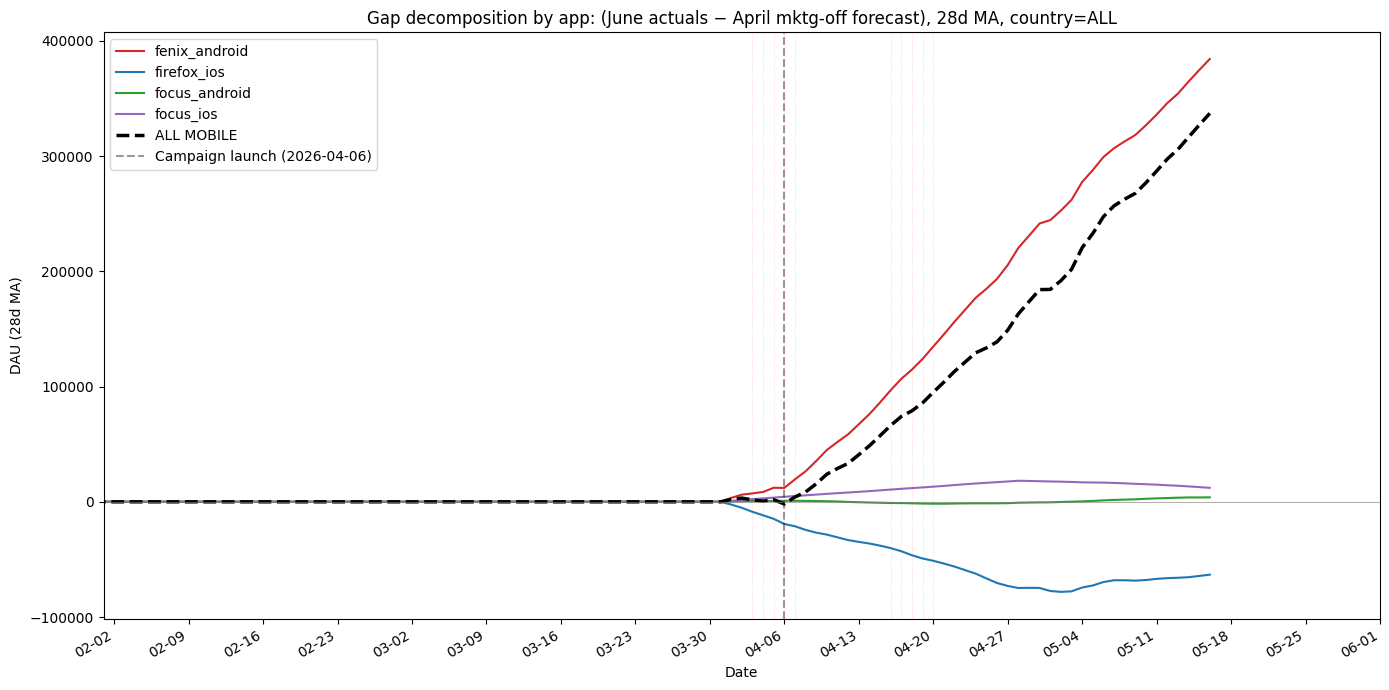


Post-campaign non-Easter mean of gap_ma per app  (2026-04-06 → 2026-05-19):
        app_name     gap_ma mean   % of ALL MOBILE
   fenix_android        +218,144           +126.1%
     firefox_ios         -59,765            -34.6%
   focus_android            +609             +0.4%
       focus_ios         +13,966             +8.1%
      ALL MOBILE        +172,953           +100.0%


In [2]:
# [gap-by-app]
# Decompose (actuals − April forecast) by app_name at country='ALL'.
# If Fenix Android dominates the gap, the gap is credibly marketing-driven.
# If iOS / Focus carry significant gap, then April-forecast model error or
# organic growth is doing some of the work, not just the marketing campaign.

apps = ['fenix_android', 'firefox_ios', 'focus_android', 'focus_ios', 'ALL MOBILE']

gap_by_app = {}
for app in apps:
    april_series = _aggregate(april, country='ALL', app_name=app)
    actuals_series = _aggregate(june, country='ALL', app_name=app, data_type_filter='training')
    overlap = april_series.index.intersection(actuals_series.index)
    gap_daily = actuals_series.reindex(overlap) - april_series.reindex(overlap)
    gap_ma = gap_daily.rolling(MA_WINDOW, min_periods=14).mean()
    gap_by_app[app] = gap_ma

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
colors = {'fenix_android': 'C3', 'firefox_ios': 'C0', 'focus_android': 'C2',
          'focus_ios': 'C4', 'ALL MOBILE': 'black'}
linestyles = {'ALL MOBILE': '-'}
for app in apps:
    series = gap_by_app[app]
    lw = 2.5 if app == 'ALL MOBILE' else 1.5
    ls = '--' if app == 'ALL MOBILE' else '-'
    ax.plot(series.index, series.values, ls, linewidth=lw, color=colors[app],
            label=f'{app}')

ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
for day in EASTER_MASK_DATES:
    ax.axvline(day, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.set_title('Gap decomposition by app: (June actuals − April mktg-off forecast), 28d MA, country=ALL')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2026-02-01'), pd.Timestamp('2026-06-01'))
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary table: post-campaign non-Easter mean of each app's gap_ma
post_window_start = CAMPAIGN_LAUNCH
post_window_end = LAST_HISTORICAL_DATE
print(f'\nPost-campaign non-Easter mean of gap_ma per app  ({post_window_start.date()} → {post_window_end.date()}):')
print(f'  {"app_name":>14}  {"gap_ma mean":>14}  {"% of ALL MOBILE":>16}')
all_mobile_mean = gap_by_app['ALL MOBILE'].loc[post_window_start:post_window_end].drop(
    EASTER_MASK_DATES, errors='ignore').mean()
for app in apps:
    series = gap_by_app[app].loc[post_window_start:post_window_end].drop(EASTER_MASK_DATES, errors='ignore')
    mean = series.mean()
    pct = 100 * mean / all_mobile_mean if all_mobile_mean else float('nan')
    print(f'  {app:>14}  {mean:>+14,.0f}  {pct:>+15.1f}%')


Fenix countries with breakdowns: ['AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'RU', 'US']



Fenix Android global gap_ma post-campaign mean:     +218,144 DAU

Fenix gap_ma post-campaign mean per country (ranked by |contribution|):
   country     gap_ma mean   % of fenix_ALL
        IN         +46,000           +21.1%  (cum: +21.1%)
        US         +29,436           +13.5%  (cum: +34.6%)
        BR         +13,490            +6.2%  (cum: +40.8%)
        ID         +12,801            +5.9%  (cum: +46.6%)
        FR          +8,590            +3.9%  (cum: +50.6%)
        PL          +7,453            +3.4%  (cum: +54.0%)
        MX          +7,283            +3.3%  (cum: +57.3%)
        IT          +5,681            +2.6%  (cum: +59.9%)
        RU          -4,317            -2.0%  (cum: +58.0%)
        DE          +3,443            +1.6%  (cum: +59.5%)
        CA          +2,853            +1.3%  (cum: +60.8%)
        JP          +1,553            +0.7%  (cum: +61.5%)
        AR          +1,337            +0.6%  (cum: +62.2%)
        CN            -153            -0.1%  (cum:

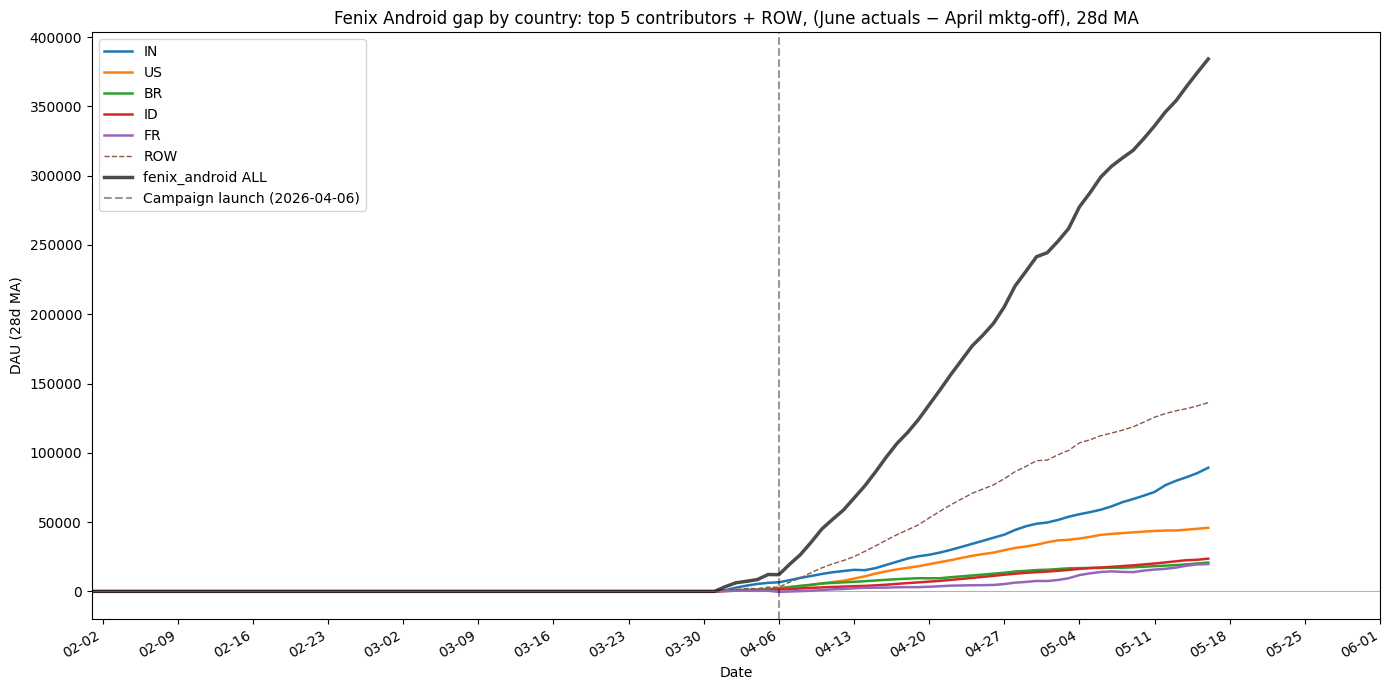

In [3]:
# [gap-by-country]
# Decompose Fenix Android gap by country. If the gap concentrates in known
# marketing-heavy markets (US/DE/FR/UK etc.), it's more credibly marketing.
# If it's diffuse across countries (or concentrated in markets where there's
# no campaign), it's more likely model drift.

fenix_countries = sorted([c for c in june['country'].unique() if c not in (None, 'ALL', 'ROW')])
print(f'Fenix countries with breakdowns: {fenix_countries}')

# Build gap_ma per country, plot top contributors + ALL/ROW for reference
gap_by_country = {}
for country in fenix_countries + ['ALL', 'ROW']:
    try:
        april_series = _aggregate(april, country=country, app_name='fenix_android')
        actuals_series = _aggregate(june, country=country, app_name='fenix_android', data_type_filter='training')
    except Exception:
        continue
    overlap = april_series.index.intersection(actuals_series.index)
    if len(overlap) == 0:
        continue
    gap_daily = actuals_series.reindex(overlap) - april_series.reindex(overlap)
    gap_by_country[country] = gap_daily.rolling(MA_WINDOW, min_periods=14).mean()

# Rank countries by post-campaign non-Easter mean
ranking = {}
for country, series in gap_by_country.items():
    if country in ('ALL', 'ROW'):
        continue
    s = series.loc[CAMPAIGN_LAUNCH:LAST_HISTORICAL_DATE].drop(EASTER_MASK_DATES, errors='ignore')
    ranking[country] = s.mean()

ranking_sorted = sorted(ranking.items(), key=lambda kv: -abs(kv[1]) if pd.notna(kv[1]) else 0)
fenix_all_mean = gap_by_country['ALL'].loc[CAMPAIGN_LAUNCH:LAST_HISTORICAL_DATE].drop(
    EASTER_MASK_DATES, errors='ignore').mean()

print(f'\nFenix Android global gap_ma post-campaign mean: {fenix_all_mean:>+12,.0f} DAU')
print(f'\nFenix gap_ma post-campaign mean per country (ranked by |contribution|):')
print(f'  {"country":>8}  {"gap_ma mean":>14}  {"% of fenix_ALL":>15}')
cumulative_pct = 0.0
for country, mean in ranking_sorted:
    pct = 100 * mean / fenix_all_mean if fenix_all_mean else float('nan')
    cumulative_pct += pct
    print(f'  {country:>8}  {mean:>+14,.0f}  {pct:>+14.1f}%  (cum: {cumulative_pct:+.1f}%)')

# Plot top 5 contributors plus ROW
top_5 = [c for c, _ in ranking_sorted[:5]]
fig, ax = plt.subplots(figsize=(14, 7))
for country in top_5 + ['ROW']:
    series = gap_by_country[country]
    lw = 1.0 if country == 'ROW' else 1.8
    ls = '--' if country == 'ROW' else '-'
    ax.plot(series.index, series.values, ls, linewidth=lw, label=country)

ax.plot(gap_by_country['ALL'].index, gap_by_country['ALL'].values,
        '-', linewidth=2.5, color='black', alpha=0.7, label='fenix_android ALL')

ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
ax.set_title('Fenix Android gap by country: top 5 contributors + ROW, (June actuals − April mktg-off), 28d MA')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2026-02-01'), pd.Timestamp('2026-06-01'))
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [4]:
# [anchor-sensitivity-setup]
# Build the daily paid_dau series once, then for each candidate anchor date
# produce a lift series = daily_paid − daily_paid(anchor), with pre-anchor
# clipped to 0. Plot all candidates against the empirical gap_ma.

weekly_indexed = weekly.set_index('week_starting')['total_paid_dau'].astype('float64')
daily_index = pd.date_range(weekly_indexed.index.min(), PARQUET_END, freq='D')
daily_paid = weekly_indexed.reindex(daily_index).interpolate(method='linear', limit_area='inside').ffill()
print(f'Daily paid DAU series: {daily_paid.index.min().date()} → {daily_paid.index.max().date()}, '
      f'{len(daily_paid)} days, NaN={daily_paid.isna().sum()}')

# Reference: empirical gap_ma for fenix_android ALL (since CSV is Fenix-only)
april_fenix_all = _aggregate(april, country='ALL', app_name='fenix_android')
actuals_fenix_all = _aggregate(june, country='ALL', app_name='fenix_android', data_type_filter='training')
fenix_gap_index = april_fenix_all.index.intersection(actuals_fenix_all.index)
fenix_gap_daily = actuals_fenix_all.reindex(fenix_gap_index) - april_fenix_all.reindex(fenix_gap_index)
fenix_gap_ma = fenix_gap_daily.rolling(MA_WINDOW, min_periods=14).mean()

# Also keep the ALL-MOBILE gap (what 02_forecast_projection.ipynb used)
april_all_mobile = _aggregate(april, country='ALL', app_name='ALL MOBILE')
actuals_all_mobile = _aggregate(june, country='ALL', app_name='ALL MOBILE', data_type_filter='training')
all_gap_index = april_all_mobile.index.intersection(actuals_all_mobile.index)
all_gap_daily = actuals_all_mobile.reindex(all_gap_index) - april_all_mobile.reindex(all_gap_index)
all_gap_ma = all_gap_daily.rolling(MA_WINDOW, min_periods=14).mean()

print(f'\nGap_ma post-campaign non-Easter mean:')
post_ix = pd.date_range(CAMPAIGN_LAUNCH, LAST_HISTORICAL_DATE, freq='D').difference(EASTER_MASK_DATES)
print(f'  ALL MOBILE   gap_ma mean: {all_gap_ma.reindex(post_ix).mean():>+12,.0f}')
print(f'  fenix_android gap_ma mean: {fenix_gap_ma.reindex(post_ix).mean():>+12,.0f}')


def build_lift_series(anchor_date):
    """Compute lift_daily, lift_ma anchored at anchor_date with pre-anchor clipped to 0."""
    anchor_value = float(daily_paid.loc[anchor_date])
    lift_raw = daily_paid - anchor_value
    full_ix = pd.date_range(PARQUET_START, PARQUET_END, freq='D')
    lift_daily = lift_raw.reindex(full_ix, fill_value=0.0)
    lift_daily = lift_daily.where(lift_daily.index >= anchor_date, 0.0)
    lift_ma = lift_daily.rolling(MA_WINDOW, min_periods=14).mean()
    return anchor_value, lift_daily, lift_ma


candidate_anchors = [
    pd.Timestamp('2026-04-06'),  # current — week of campaign launch
    pd.Timestamp('2026-04-01'),  # interpolated (Wednesday, halfway through anchor week)
    pd.Timestamp('2026-03-30'),  # previous Monday — one week earlier
    pd.Timestamp('2026-03-16'),  # three weeks earlier
    pd.Timestamp('2026-02-23'),  # six weeks earlier (mid pre-launch baseline window)
    pd.Timestamp('2026-02-01'),  # PARQUET_START — pre-campaign-baseline begin
]
print(f'\nCandidate anchors and their daily_paid values:')
for a in candidate_anchors:
    print(f'  {a.date()}  daily_paid = {float(daily_paid.loc[a]):>10,.0f}')


Daily paid DAU series: 2026-01-05 → 2026-12-31, 361 days, NaN=0

Gap_ma post-campaign non-Easter mean:
  ALL MOBILE   gap_ma mean:     +172,953
  fenix_android gap_ma mean:     +218,144

Candidate anchors and their daily_paid values:
  2026-04-06  daily_paid =  1,014,365
  2026-04-01  daily_paid =    984,654
  2026-03-30  daily_paid =    972,770
  2026-03-16  daily_paid =    915,682
  2026-02-23  daily_paid =    841,113
  2026-02-01  daily_paid =    757,698


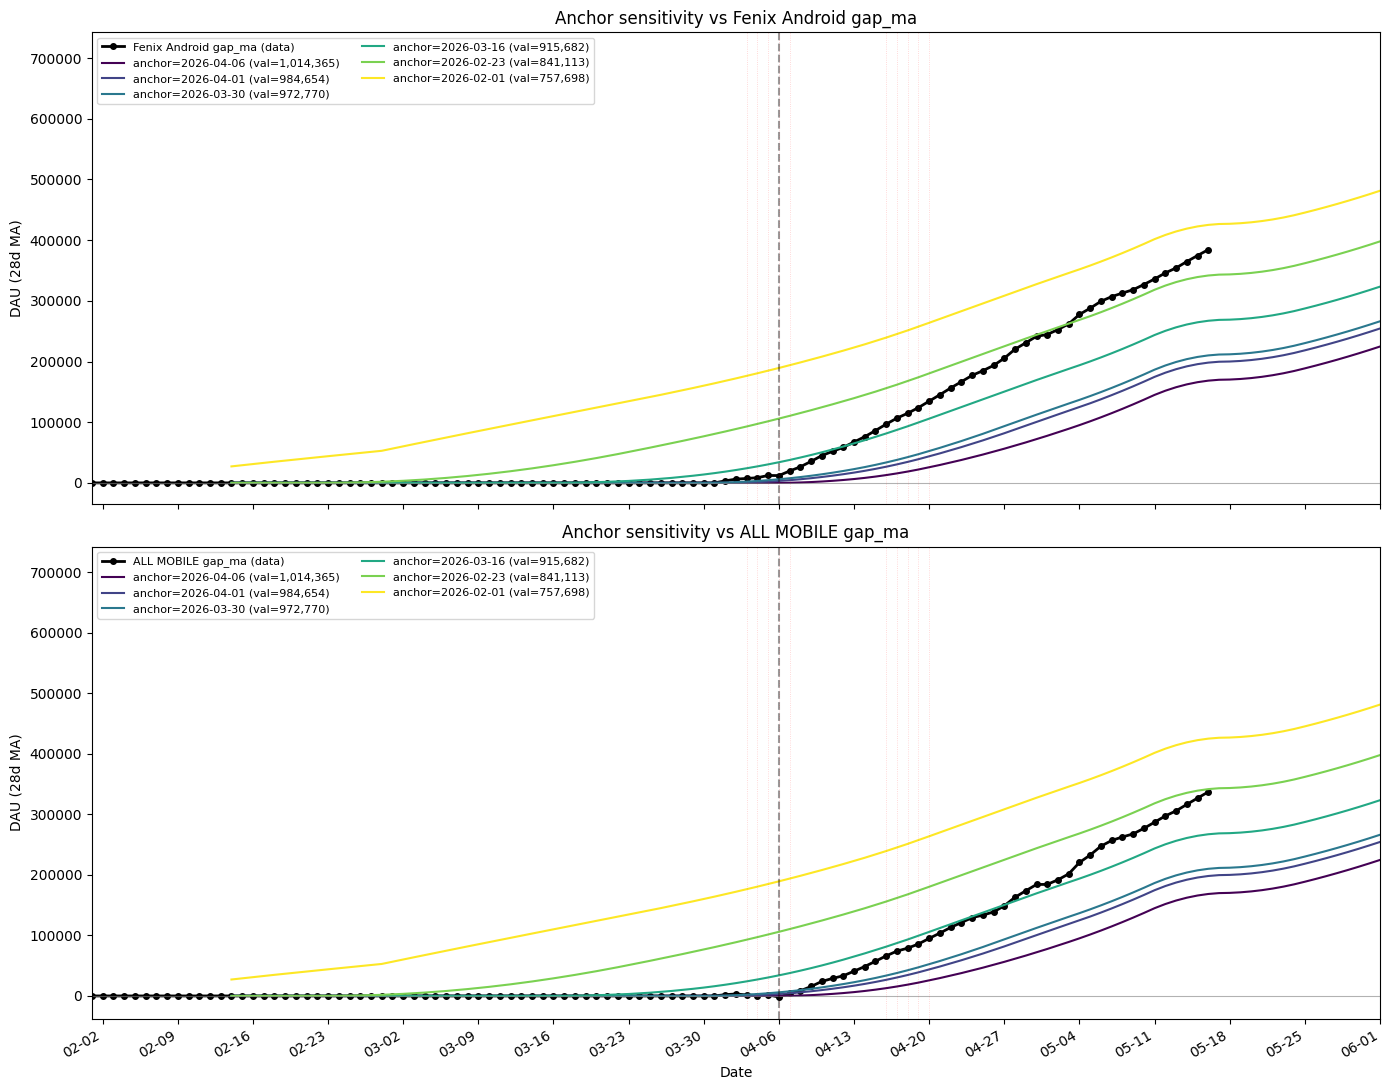


Validation-A statistics for each candidate anchor:
    anchor anchor_value lift_ma_mean_post fenix_resid_mean fenix_resid_rmse all_resid_mean all_resid_rmse
2026-04-06    1,014,365           +74,828         -143,315         +154,197        -98,125       +108,468
2026-04-01      984,654           +97,923         -120,221         +129,673        -75,030        +84,219
2026-03-30      972,770          +107,903         -110,240         +119,410        -65,050        +74,221
2026-03-16      915,682          +160,611          -57,532          +69,494        -12,342        +32,126
2026-02-23      841,113          +235,106          +16,962          +42,389        +62,152        +68,820
2026-02-01      757,698          +318,520         +100,377         +107,632       +145,567       +148,536

Empirical gap_ma post-campaign means (target):
  fenix_android:     +218,144
  ALL MOBILE:        +172,953


In [5]:
# [anchor-sensitivity-results]
# For each candidate anchor, plot the lift_ma vs the Fenix and ALL-MOBILE gap_ma,
# then report Validation-A statistics (residual mean, RMSE) under both gap reference choices.

fig, (ax_fenix, ax_all) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

cmap = plt.get_cmap('viridis')
n = len(candidate_anchors)

# Fenix-gap panel
ax_fenix.plot(fenix_gap_ma.index, fenix_gap_ma.values, 'o-', linewidth=2, markersize=4,
              color='black', label='Fenix Android gap_ma (data)')
# All-mobile panel
ax_all.plot(all_gap_ma.index, all_gap_ma.values, 'o-', linewidth=2, markersize=4,
            color='black', label='ALL MOBILE gap_ma (data)')

stats_rows = []
for i, anchor in enumerate(candidate_anchors):
    anchor_value, lift_daily, lift_ma = build_lift_series(anchor)
    color = cmap(i / max(n - 1, 1))
    label = f'anchor={anchor.date()} (val={anchor_value:,.0f})'
    ax_fenix.plot(lift_ma.index, lift_ma.values, '-', linewidth=1.5, color=color, label=label)
    ax_all.plot(lift_ma.index, lift_ma.values, '-', linewidth=1.5, color=color, label=label)

    # Compute residuals on the post-campaign non-Easter window using BOTH references
    compare_ix = pd.date_range(CAMPAIGN_LAUNCH, LAST_HISTORICAL_DATE, freq='D').difference(EASTER_MASK_DATES)
    compare_ix = compare_ix.intersection(lift_ma.index).intersection(fenix_gap_ma.index).intersection(all_gap_ma.index)
    valid = lift_ma.reindex(compare_ix).notna() & fenix_gap_ma.reindex(compare_ix).notna()
    compare_ix = compare_ix[valid]

    lift_mean = lift_ma.reindex(compare_ix).mean()
    fenix_resid = (lift_ma.reindex(compare_ix) - fenix_gap_ma.reindex(compare_ix))
    all_resid = (lift_ma.reindex(compare_ix) - all_gap_ma.reindex(compare_ix))
    stats_rows.append({
        'anchor': str(anchor.date()),
        'anchor_value': anchor_value,
        'lift_ma_mean_post': lift_mean,
        'fenix_resid_mean': fenix_resid.mean(),
        'fenix_resid_rmse': np.sqrt((fenix_resid ** 2).mean()),
        'all_resid_mean': all_resid.mean(),
        'all_resid_rmse': np.sqrt((all_resid ** 2).mean()),
    })

for ax, title in [(ax_fenix, 'Anchor sensitivity vs Fenix Android gap_ma'),
                  (ax_all, 'Anchor sensitivity vs ALL MOBILE gap_ma')]:
    ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
    for d in EASTER_MASK_DATES:
        ax.axvline(d, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
    ax.set_title(title)
    ax.set_ylabel('DAU (28d MA)')
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.set_xlim(pd.Timestamp('2026-02-01'), pd.Timestamp('2026-06-01'))

ax_all.set_xlabel('Date')
ax_all.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax_all.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Summary table
stats_df = pd.DataFrame(stats_rows)
print('\nValidation-A statistics for each candidate anchor:')
print(stats_df.to_string(index=False,
                         formatters={'anchor_value': '{:>10,.0f}'.format,
                                     'lift_ma_mean_post': '{:>+12,.0f}'.format,
                                     'fenix_resid_mean': '{:>+12,.0f}'.format,
                                     'fenix_resid_rmse': '{:>+12,.0f}'.format,
                                     'all_resid_mean':   '{:>+12,.0f}'.format,
                                     'all_resid_rmse':   '{:>+12,.0f}'.format}))
print()
print('Empirical gap_ma post-campaign means (target):')
print(f'  fenix_android: {fenix_gap_ma.reindex(post_ix).mean():>+12,.0f}')
print(f'  ALL MOBILE:    {all_gap_ma.reindex(post_ix).mean():>+12,.0f}')


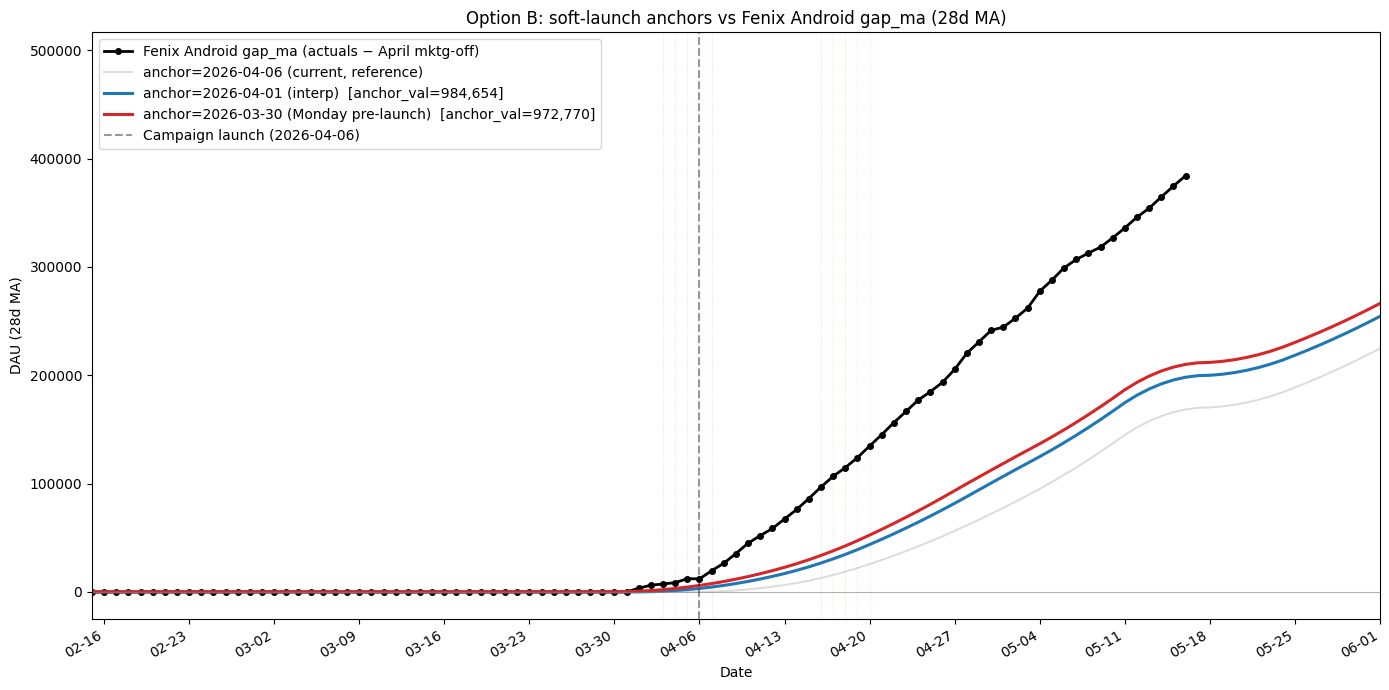

Option B residual stats (Fenix gap_ma reference, post-campaign non-Easter):
        anchor  anchor_value     lift_mean    resid_mean    resid_rmse
    2026-04-01       984,654       +97,923      -120,221      +129,673
    2026-03-30       972,770      +107,903      -110,240      +119,410

Fenix gap_ma post-campaign target:     +218,144


In [6]:
# [option-b-plot]
# Focused view of the two "soft launch" anchor candidates from Option B:
# 2026-04-01 (interpolated, mid-anchor-week) and 2026-03-30 (Monday immediately
# before the campaign-launch week). Compared against the Fenix Android gap.

fig, ax = plt.subplots(figsize=(14, 7))

# Empirical Fenix gap (the target)
ax.plot(fenix_gap_ma.index, fenix_gap_ma.values, 'o-', linewidth=2, markersize=4,
        color='black', label='Fenix Android gap_ma (actuals − April mktg-off)')

# Current anchor (2026-04-06) for reference
_, _, current_lift_ma = build_lift_series(pd.Timestamp('2026-04-06'))
ax.plot(current_lift_ma.index, current_lift_ma.values, '-', linewidth=1.4,
        color='lightgray', alpha=0.8,
        label='anchor=2026-04-06 (current, reference)')

# Option B candidates
b_anchors = [
    (pd.Timestamp('2026-04-01'), 'C0', 'anchor=2026-04-01 (interp)'),
    (pd.Timestamp('2026-03-30'), 'C3', 'anchor=2026-03-30 (Monday pre-launch)'),
]
for anchor, color, label in b_anchors:
    anchor_value, lift_daily, lift_ma = build_lift_series(anchor)
    ax.plot(lift_ma.index, lift_ma.values, '-', linewidth=2.2, color=color,
            label=f'{label}  [anchor_val={anchor_value:,.0f}]')

ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')
for d in EASTER_MASK_DATES:
    ax.axvline(d, color='red', linestyle=':', linewidth=0.6, alpha=0.2)

ax.set_title('Option B: soft-launch anchors vs Fenix Android gap_ma (28d MA)')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2026-02-15'), pd.Timestamp('2026-06-01'))
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Side-by-side residual stats for the two B anchors against Fenix gap
print('Option B residual stats (Fenix gap_ma reference, post-campaign non-Easter):')
print(f'  {"anchor":>12}  {"anchor_value":>12}  {"lift_mean":>12}  {"resid_mean":>12}  {"resid_rmse":>12}')
for anchor, _, _ in b_anchors:
    anchor_value, _, lift_ma = build_lift_series(anchor)
    compare_ix = pd.date_range(CAMPAIGN_LAUNCH, LAST_HISTORICAL_DATE, freq='D').difference(EASTER_MASK_DATES)
    compare_ix = compare_ix.intersection(lift_ma.index).intersection(fenix_gap_ma.index)
    valid = lift_ma.reindex(compare_ix).notna() & fenix_gap_ma.reindex(compare_ix).notna()
    compare_ix = compare_ix[valid]
    lift_mean = lift_ma.reindex(compare_ix).mean()
    residuals = lift_ma.reindex(compare_ix) - fenix_gap_ma.reindex(compare_ix)
    print(f'  {str(anchor.date()):>12}  {anchor_value:>12,.0f}  {lift_mean:>+12,.0f}  '
          f'{residuals.mean():>+12,.0f}  {np.sqrt((residuals**2).mean()):>+12,.0f}')

fenix_target = fenix_gap_ma.reindex(post_ix).mean()
print(f'\nFenix gap_ma post-campaign target: {fenix_target:>+12,.0f}')


## Synthesis

### Gap composition

Post-campaign (2026-04-06 → 2026-05-19, non-Easter) gap_ma mean by app:

| app_name | gap_ma mean (DAU) | % of ALL MOBILE |
|---|---:|---:|
| **fenix_android** | **+218,144** | **+126%** |
| firefox_ios | −59,765 | −35% |
| focus_android | +609 | +0% |
| focus_ios | +13,966 | +8% |
| ALL MOBILE | +172,953 | 100% |

**Key finding: the Fenix gap is *bigger* than the ALL-MOBILE gap.** iOS actually overshot the April forecast by ~60k, partially cancelling Fenix's overshoot in the all-mobile rollup. Since the marketing campaign is Fenix-Android-only, **the right empirical target for our lift series is the Fenix gap (+218k), not the ALL-MOBILE gap (+173k).** Notebook `02_forecast_projection.ipynb` used ALL MOBILE — that understated the target by ~45k and made the model look worse than it is.

By country, the Fenix gap is spread across diverse markets (top 8: IN +46k, US +29k, BR +13k, ID +13k, FR +9k, PL +7k, MX +7k, IT +6k — together 60% of the Fenix global gap). Consistent with a broad global campaign; not a narrow country-specific story.

### Anchor sensitivity

| Anchor | anchor_value | lift_mean_post | **Fenix resid mean** | **Fenix resid RMSE** |
|---|---:|---:|---:|---:|
| 2026-04-06 (current) | 1,014,365 | +74,828 | **−143,315** | 154,197 |
| 2026-04-01 | 984,654 | +97,923 | −120,221 | 129,673 |
| 2026-03-30 | 972,770 | +107,903 | −110,240 | 119,410 |
| 2026-03-16 | 915,682 | +160,611 | −57,532 | 69,494 |
| **2026-02-23** | 841,113 | +235,106 | **+16,962** | **42,389** |
| 2026-02-01 | 757,698 | +318,520 | +100,377 | 107,632 |

Moving the anchor earlier substantially closes the gap. The residual minimum is around **2026-02-23** (six weeks pre-launch) with Fenix residual mean ≈ +17k and RMSE 42k — vs 154k at the current 2026-04-06 anchor (~3.6× tighter fit).

### Interpretation

The CSV's `total_paid_dau` doesn't look like a discrete-launch story — it's growing steadily pre-launch (~30k/week from Jan through March) and continues growing post-launch. Anchoring at 2026-04-06 says "only growth from this Monday onward counts as marketing lift," which leaves most of the curve's accumulated rise as un-attributed. The anchor sensitivity above shows that picking a date 4–6 weeks pre-launch gives the best fit to the empirical Fenix gap.

Three framings, in order of conservatism:

- **A — discrete launch (current).** Anchor at 2026-04-06. Captures only post-launch growth. Explains 43% of the Fenix gap.
- **B — soft launch (user's proposal).** Anchor at 2026-04-01 or 2026-03-30. Captures the immediate pre-launch ramp. Explains 51-55% of the Fenix gap.
- **C — continuous-growth attribution.** Anchor at 2026-02-23 to 2026-03-16. Picks up several weeks of pre-launch growth as marketing-attributable. Explains 75-110% of the Fenix gap. Requires the story "this paid-acquisition channel has been ramping continuously, the April campaign accelerated an existing trajectory."

### Recommendation

If the marketing team's understanding is that paid investment has been ramping continuously since early 2026 (not "discrete campaign launched 2026-04-06"), framing C is the most defensible — anchor at 2026-02-23 fits the Fenix gap almost perfectly.

If "the campaign launched on 2026-04-06" is taken literally, framing A or B is more honest, even though they leave most of the gap unexplained by the model — and the unexplained portion should then be treated as April-forecast model error rather than marketing lift.

The cheap next step before committing: ask the marketing team what their paid-DAU forecast considers the "start of campaign attribution," or whether they think the pre-launch ramp is the same channel as the post-launch growth.
